# Large Language Models (LLMs) for Text Classification Benchmark

**Author:** Alireza Mirzadeh  
**Project:** LLM Text Classification Benchmark  
**Dataset:** Rotten Tomatoes (Hugging Face Datasets)  
**Notebook:** 03 — Transformer Models 

---

## Project Overview

This project provides a comprehensive benchmark of text classification techniques, progressing from classical machine learning methods to transformer-based models and large language models (LLMs). The implementation emphasizes reproducibility, modular software design, and rigorous experimental evaluation.

### Project Links

- **GitHub Repository:** *[llm-text-classification-benchmark](https://github.com/Alireza-Mirzadeh/llm-text-classification-benchmark)*

- **LinkedIn:** *[Alireza Mirzadeh](https://www.linkedin.com/in/alireza-mirzadeh/)*

---

# Transformer-based text classification

## Objective


In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
from src.data_loader import RottenTomatoesDataLoader

import pandas as pd
import matplotlib.pyplot as plt

from src.models.hf_pipeline_classifier import HuggingFacePipelineClassifier
from src.evaluation import evaluate_classifier, plot_confusion_matrix

from tqdm.auto import tqdm

from sklearn.metrics.pairwise import cosine_similarity


# 0- Data Preparation

In [3]:
# Load the Rotten Tomatoes dataset using the data_loader from the src
loader = RottenTomatoesDataLoader()

dataset = loader.load_dataset_local()

# Create train, validation, and test splits
train_ds = dataset["train"]
validation_ds = dataset["validation"]
test_ds = dataset["test"]

# Convert to pands DataFrames
train_df = train_ds.to_pandas()
validation_df = validation_ds.to_pandas()
test_df = test_ds.to_pandas()

print(f"Train dataset shape: {train_df.shape}")
print(f"Validation dataset shape: {validation_df.shape}")
print(f"Test dataset shape: {test_df.shape}")


Train dataset shape: (8530, 2)
Validation dataset shape: (1066, 2)
Test dataset shape: (1066, 2)


In [4]:
# Display class distribution for each split
for split_name, split_df in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():
    print(
        f"{split_name.capitalize()} dataset class distribution: \n\n{split_df['label'].value_counts(normalize=True)}\n"
    )


Train dataset class distribution: 

label
1    0.5
0    0.5
Name: proportion, dtype: float64

Validation dataset class distribution: 

label
1    0.5
0    0.5
Name: proportion, dtype: float64

Test dataset class distribution: 

label
1    0.5
0    0.5
Name: proportion, dtype: float64



# 1- Task-specific Sentiment Model

Model:
cardiffnlp/twitter-roberta-base-sentiment-latest

In [5]:
# Load congifuration
config = loader.config

# Initialize the HuggingFacePipelineClassifier with the specified model name, batch size, and device from the configuration
model = HuggingFacePipelineClassifier(
    model_name=config["models"]["task_specific"]["model_name"],
    batch_size=config["models"]["task_specific"]["batch_size"],
    device=config["models"]["task_specific"]["device"],
)

# Initialize the model (this will load the pre-trained model and tokenizer)
model.fit()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


HuggingFacePipelineClassifier(model_name='cardiffnlp/twitter-roberta-base-sentiment-latest')

In [6]:
# Predict on the test set
y_pred = model.predict(test_ds, verbose=True)


Predicting:   0%|          | 0/1066 [00:00<?, ?it/s]

Output: [{'label': 'positive', 'score': 0.9546052813529968}, {'label': 'neutral', 'score': 0.04023349657654762}, {'label': 'negative', 'score': 0.00516123604029417}]
Scores: {'positive': 0.9546052813529968, 'neutral': 0.04023349657654762, 'negative': 0.00516123604029417}
Prediction: 1 

Output: [{'label': 'positive', 'score': 0.8883835673332214}, {'label': 'neutral', 'score': 0.10391006618738174}, {'label': 'negative', 'score': 0.007706424221396446}]
Scores: {'positive': 0.8883835673332214, 'neutral': 0.10391006618738174, 'negative': 0.007706424221396446}
Prediction: 1 

Output: [{'label': 'negative', 'score': 0.7359192371368408}, {'label': 'neutral', 'score': 0.24242684245109558}, {'label': 'positive', 'score': 0.021653952077031136}]
Scores: {'negative': 0.7359192371368408, 'neutral': 0.24242684245109558, 'positive': 0.021653952077031136}
Prediction: 0 

Output: [{'label': 'positive', 'score': 0.9342906475067139}, {'label': 'neutral', 'score': 0.06267126649618149}, {'label': 'negative

In [7]:
# Inspect the predictions with a DataFrame containing the text, true labels, and predicted labels
y_pred_df = pd.DataFrame({"text": test_ds["text"], "true_label": test_ds["label"], "predicted_label": y_pred})
y_pred_df

,text,true_label,predicted_label
0,lovingly photographed in the manner of a golde...,1,1
1,consistently clever and suspenseful .,1,1
2,"it's like a "" big chill "" reunion of the baade...",1,0
3,the story gives ample opportunity for large-sc...,1,1
4,"red dragon "" never cuts corners .",1,1
...,...,...,...
1061,a terrible movie that some people will neverth...,0,0
1062,there are many definitions of 'time waster' bu...,0,0
1063,"as it stands , crocodile hunter has the hurrie...",0,0
1064,the thing looks like a made-for-home-video qui...,0,0


In [8]:
# Evaluate the model's performance on the test set using accuracy, precision, recall, and F1-score
metrics, report = evaluate_classifier(test_ds["label"], y_pred)

print("Task-Specific Transformer Sentiment Model")

for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value:.2f}")

Task-Specific Transformer Sentiment Model
accuracy: 0.80
precision: 0.86
recall: 0.72
f1: 0.78


In [9]:
# Create a DataFrame from the classification report for better visualization
report_df_sentiment_model = pd.DataFrame(report).transpose()

report_df_sentiment_model

,precision,recall,f1-score,support
negative,0.758900,0.879925,0.814944,533.000000
positive,0.857143,0.720450,0.782875,533.000000
accuracy,0.800188,0.800188,0.800188,0.800188
macro avg,0.808021,0.800188,0.798909,1066.000000
weighted avg,0.808021,0.800188,0.798909,1066.000000


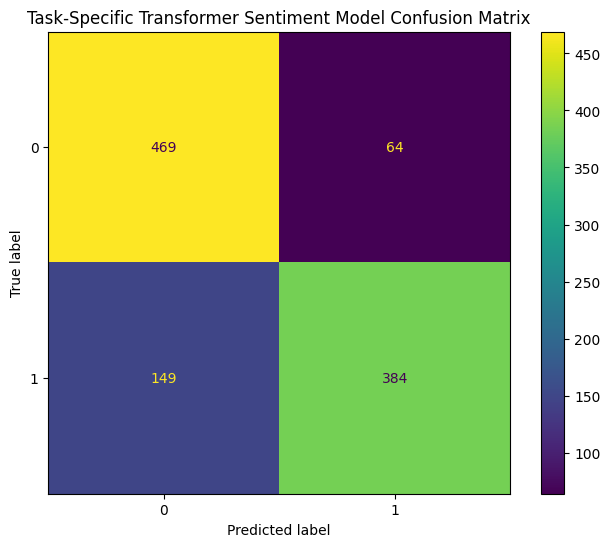

In [10]:
# Confusion matrix for the task-specific transformer sentiment model
plot_confusion_matrix("Task-Specific Transformer Sentiment Model", test_ds["label"], y_pred)

plt.show()

In [11]:
# Load benchmark results for comparison
benchmark_results_path = Path("reports/results/benchmark_results.csv")

benchmark_df = pd.read_csv(benchmark_results_path)

results = []
results.append(
    {
        "model": "Task-Specific Transformer (cardiffnlp)",
        **metrics
    }
)
# Add the task-specific transformer model results to the benchmark results DataFrame
benchmark_df = pd.concat([benchmark_df, pd.DataFrame(results)], ignore_index=True)

# Drop the "Rank" column from the benchmark DataFrame 
benchmark_df.drop(columns=["Rank"], inplace=True)

# Sort the benchmark DataFrame by F1 score in descending order and reset the index
benchmark_df = (
    benchmark_df
    .sort_values(by="f1", ascending=False)
    .reset_index(drop=True)
)

# Set the index to start from 1 and rename the index column to "Rank"
benchmark_df.index += 1
benchmark_df.index.name = "Rank"

# Round the metrics to 3 decimal places for better readability
benchmark_df = benchmark_df.round(3)

benchmark_df

,model,accuracy,precision,recall,f1
Rank,,,,,
1,Task-Specific Transformer (cardiffnlp),0.800,0.857,0.720,0.783
2,TF-IDF + Logistic Regression,0.780,0.783,0.777,0.780
3,Bag-of-Words + Logistic Regression,0.769,0.773,0.762,0.767
4,TF-IDF + Linear SVM,0.763,0.771,0.747,0.759
5,Majority Class Baseline,0.500,0.000,0.000,0.000


# 2-Classification Tasks that leverages Embeddings

## 2.1- Supervised Classification with Embeddings

Embedding Model:
- sentence-transformers/all-mpnet-base-v2

Classifier:
- Logistic Regression


In [12]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression


In [13]:
# Initialize the embedding model using the SentenceTransformer class with the specified model name from the configuration. This model will be used to generate embeddings for the text data.
embedding_model = SentenceTransformer(config["models"]["embeddings"]["model_name"])


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

The `all-mpnet-base-v2` model converts text into a 768-dimensional dense vector representation.

Unlike TF-IDF, embeddings capture semantic similarity between words and sentences.

For example:

"the movie was excellent"

and

"this film was amazing"

will have similar vector representations.

In [14]:
# Generate embeddings for the training data
train_embeddings = embedding_model.encode(train_ds["text"], batch_size=config["models"]["embeddings"]["batch_size"], show_progress_bar=True)

# Generate embeddings for the test data
test_embeddings = embedding_model.encode(test_ds["text"], batch_size=config["models"]["embeddings"]["batch_size"], show_progress_bar=True)


Batches:   0%|          | 0/267 [00:00<?, ?it/s]

Batches:   0%|          | 0/34 [00:00<?, ?it/s]

In [15]:
# print the shape of the generated embeddings for the training data and test data to verify the dimensions
print(f"Training embeddings shape: {train_embeddings.shape}")
print(f"Test embeddings shape: {test_embeddings.shape}")

Training embeddings shape: (8530, 768)
Test embeddings shape: (1066, 768)


In [16]:
# Train logistic regression classifier on the generated embeddings
classifier = LogisticRegression(max_iter=1000, random_state=42)

# Fit the logistic regression classifier on the training embeddings and labels
classifier.fit(train_embeddings, train_ds["label"])


LogisticRegression(max_iter=1000, random_state=42)

In [17]:
# Make predictions on the test embeddings using the trained logistic regression classifier
y_pred_embeddings = classifier.predict(test_embeddings)

print(f"Prediction shape: {y_pred_embeddings.shape}")

Prediction shape: (1066,)


In [18]:
# Evaluate the model's performance on the test set using accuracy, precision, recall, and F1-score
metrics_embeddings, report_embeddings = evaluate_classifier(test_ds["label"], y_pred_embeddings)

print("Embedding-based Logistic Regression Model")

for metric_name, metric_value in metrics_embeddings.items():
    print(f"{metric_name}: {metric_value:.2f}")


Embedding-based Logistic Regression Model
accuracy: 0.85
precision: 0.86
recall: 0.85
f1: 0.85


In [19]:
# Create a DataFrame from the classification report for better visualization
report_df_embeddings = pd.DataFrame(report_embeddings).transpose()
report_df_embeddings

,precision,recall,f1-score,support
negative,0.847866,0.857411,0.852612,533.000000
positive,0.855787,0.846154,0.850943,533.000000
accuracy,0.851782,0.851782,0.851782,0.851782
macro avg,0.851827,0.851782,0.851778,1066.000000
weighted avg,0.851827,0.851782,0.851778,1066.000000


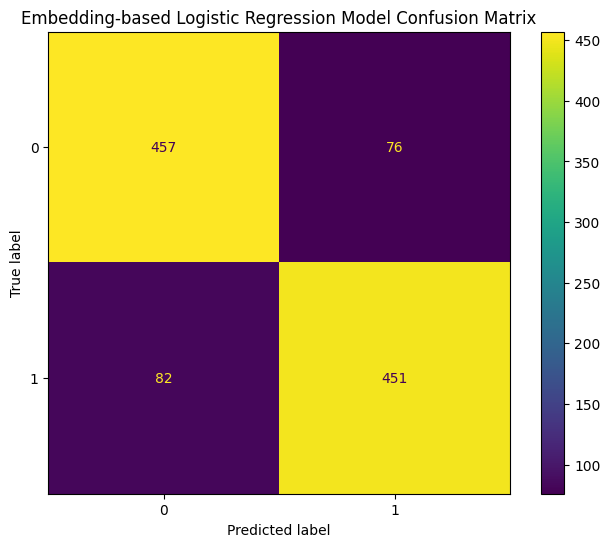

In [20]:
# Confusion matrix for the embedding-based logistic regression model
plot_confusion_matrix("Embedding-based Logistic Regression Model", test_ds["label"], y_pred_embeddings)
plt.show()


In [21]:
# Add the embedding-based logistic regression model results to the benchmark results DataFrame 
results.append(
    {
        "model": "Embedding-based Logistic Regression (all-mpnet-base-v2)",
        **metrics_embeddings
    }
)
# Add the task-specific transformer model results to the benchmark results DataFrame
benchmark_df = pd.concat([benchmark_df, pd.DataFrame(results)], ignore_index=True)

benchmark_df = benchmark_df.drop_duplicates(
    subset=["model"],
    keep="last"
)

# Sort the benchmark DataFrame by F1 score in descending order and reset the index
benchmark_df = (
    benchmark_df
    .sort_values(by="f1", ascending=False)
    .reset_index(drop=True)
)

# Set the index to start from 1 and rename the index column to "Rank"
benchmark_df.index += 1
benchmark_df.index.name = "Rank"

# Round the metrics to 3 decimal places for better readability
benchmark_df = benchmark_df.round(3)

benchmark_df

,model,accuracy,precision,recall,f1
Rank,,,,,
1,Embedding-based Logistic Regression (all-mpnet...,0.852,0.856,0.846,0.851
2,Task-Specific Transformer (cardiffnlp),0.800,0.857,0.720,0.783
3,TF-IDF + Logistic Regression,0.780,0.783,0.777,0.780
4,Bag-of-Words + Logistic Regression,0.769,0.773,0.762,0.767
5,TF-IDF + Linear SVM,0.763,0.771,0.747,0.759
6,Majority Class Baseline,0.500,0.000,0.000,0.000


## Results Discussion

The embedding-based classification approach achieved the best performance among the evaluated models, reaching an accuracy of **85.2%** and an F1-score of **85.1%**.

Compared with traditional sparse representations such as Bag-of-Words and TF-IDF, sentence embeddings provide richer semantic representations by capturing contextual meaning beyond individual word frequencies. This allows the classifier to better distinguish sentiment patterns in movie reviews.

Interestingly, the frozen sentence embedding approach also outperformed the task-specific sentiment transformer model. One possible explanation is the domain difference between the models: the task-specific transformer was trained on Twitter sentiment data, while the Rotten Tomatoes dataset contains longer and more formal movie reviews. The general-purpose sentence embedding model may therefore provide representations that transfer better to this domain.

These results highlight the effectiveness of combining pretrained language representations with lightweight classical classifiers.

## 2.2- Zero-shot Classification with Sentence Embeddings

## Zero-Shot Classification using Semantic Similarity

Unlike the previous experiment, this approach does **not** train a classifier.

Instead, both the documents and the class descriptions are embedded into the same semantic vector space. Predictions are obtained by assigning each document to the label whose embedding has the highest cosine similarity.

Pipeline:

Review

    ↓

Sentence Transformer

    ↓

Embedding

    ↓
Cosine Similarity of Review Embedding with Class Embeddings

    ↓
Prediction

In [22]:
# Label Embeddings for Zero-shot Classification
labels_description = ["A negative movie review", "A positive movie review"]

# Generate embeddings for the class descriptions using the same embedding model
label_embeddings = embedding_model.encode(labels_description, show_progress_bar=True, convert_to_numpy=True)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [23]:
# Similarity scores between test embeddings and label embeddings for zero-shot classification
similarity_scores = cosine_similarity(test_embeddings, label_embeddings)

# Print the shape of the similarity scores to verify the dimensions
print(f"Similarity scores shape: {similarity_scores.shape}")

Similarity scores shape: (1066, 2)


In [24]:
# Predict the labels for the test set based on the highest cosine similarity scores
y_pred_zero_shot = similarity_scores.argmax(axis=1)


In [25]:
# Evaluate the zero-shot classification model's performance on the test set using accuracy, precision, recall, and F1-score
metrics_zero_shot, report_zero_shot = evaluate_classifier(test_ds["label"], y_pred_zero_shot)

print("Zero-shot Classification with Sentence Embeddings")

for metric_name, metric_value in metrics_zero_shot.items():
    print(f"{metric_name}: {metric_value:.2f}")
    

Zero-shot Classification with Sentence Embeddings
accuracy: 0.80
precision: 0.78
recall: 0.85
f1: 0.81


In [26]:
# DataFrame from the classification report for better visualization
report_df_zero_shot = pd.DataFrame(report_zero_shot).transpose()
report_df_zero_shot

,precision,recall,f1-score,support
negative,0.830928,0.756098,0.791749,533.000000
positive,0.776248,0.846154,0.809695,533.000000
accuracy,0.801126,0.801126,0.801126,0.801126
macro avg,0.803588,0.801126,0.800722,1066.000000
weighted avg,0.803588,0.801126,0.800722,1066.000000


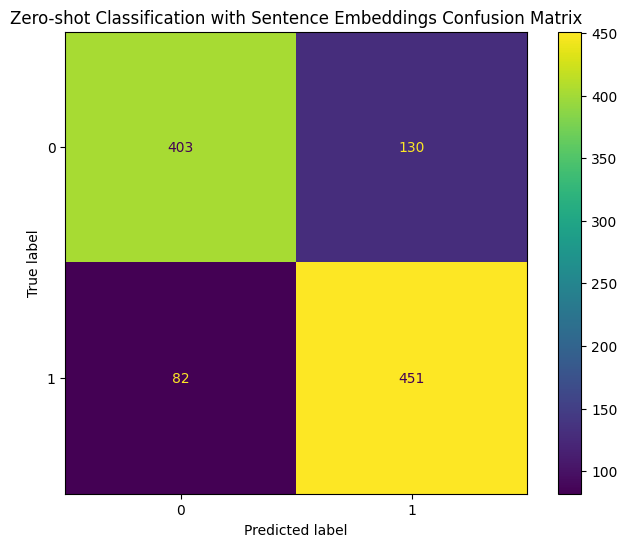

In [27]:
# Confusion matrix for the zero-shot classification model with sentence embeddings
plot_confusion_matrix("Zero-shot Classification with Sentence Embeddings", test_ds["label"], y_pred_zero_shot)
plt.show()


In [28]:
# Add the embedding-based zero-shot model results to the benchmark results DataFrame 
results.append(
    {
        "model": "Embedding Zero-Shot Classification (all-mpnet-base-v2)",
        **metrics_zero_shot
    }
)
# Add the task-specific transformer model results to the benchmark results DataFrame
benchmark_df = pd.concat([benchmark_df, pd.DataFrame(results)], ignore_index=True)

benchmark_df = benchmark_df.drop_duplicates(
    subset=["model"],
    keep="last"
)

# Sort the benchmark DataFrame by F1 score in descending order and reset the index
benchmark_df = (
    benchmark_df
    .sort_values(by="f1", ascending=False)
    .reset_index(drop=True)
)

# Set the index to start from 1 and rename the index column to "Rank"
benchmark_df.index += 1
benchmark_df.index.name = "Rank"

# Round the metrics to 3 decimal places for better readability
benchmark_df = benchmark_df.round(3)

benchmark_df

,model,accuracy,precision,recall,f1
Rank,,,,,
1,Embedding-based Logistic Regression (all-mpnet...,0.852,0.856,0.846,0.851
2,Embedding Zero-Shot Classification (all-mpnet-...,0.801,0.776,0.846,0.810
3,Task-Specific Transformer (cardiffnlp),0.800,0.857,0.720,0.783
4,TF-IDF + Logistic Regression,0.780,0.783,0.777,0.780
5,Bag-of-Words + Logistic Regression,0.769,0.773,0.762,0.767
6,TF-IDF + Linear SVM,0.763,0.771,0.747,0.759
7,Majority Class Baseline,0.500,0.000,0.000,0.000
